# 07. RAG for Causal Domain Knowledge

Retrieval-augmented generation is useful in causal inference when the model needs **domain knowledge** that is not in the prompt: rollout rules, metric definitions, eligibility criteria, data lineage, experiment notes, business constraints, compliance language, and previous analysis decisions.

But RAG does not make causal inference automatic. A retrieved document can tell us what the business believes, what was logged, what rules existed, or what metric changed. It cannot, by itself, prove exchangeability, validate an exclusion restriction, or certify parallel trends. In causal work, RAG should be treated as an evidence-management layer that helps analysts surface assumptions and cite them clearly.


## Learning Goals

By the end of this notebook you should be able to:

1. Explain why causal RAG is different from generic question answering.
2. Build a small domain knowledge base with document metadata and chunk-level source IDs.
3. Retrieve causal-relevant context for questions about treatment, outcome, timing, controls, guardrails, and measurement.
4. Generate a structured answer that separates evidence, assumptions, caveats, and next steps.
5. Audit whether an LLM answer is grounded in retrieved sources.
6. Compare all available local models on a causal RAG task using schema reliability and causal-grounding scores.


## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. Setup

The notebook is safe to render with live model calls off. The retrieval examples run deterministically using a small local corpus and scikit-learn. Live local LLM calls are optional and should be run in an interactive GPU session.


In [1]:
import gc
import importlib.util
import json
import re
import textwrap
from functools import lru_cache
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 1800
TEMPERATURE = 0.0
SEED = 207
TOP_K = 5
MODEL_COMPARISON_CASE_LIMIT = 1

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)


In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM generation'},
        {'package': 'sentence_transformers', 'available': has_package('sentence_transformers'), 'used_for': 'optional dense embeddings'},
        {'package': 'faiss', 'available': has_package('faiss'), 'used_for': 'optional vector indexing'},
        {'package': 'sklearn', 'available': has_package('sklearn'), 'used_for': 'deterministic TF-IDF retrieval in this notebook'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status


CUDA available to this kernel: True


,package,available,used_for
0,transformers,True,optional local LLM generation
1,sentence_transformers,True,optional dense embeddings
2,faiss,True,optional vector indexing
3,sklearn,True,deterministic TF-IDF retrieval in this notebook
4,torch,True,GPU inference if live LLMs are enabled


## 2. Why RAG Is Useful in Causal Work

A causal analyst often has two kinds of uncertainty:

1. **Statistical uncertainty**: sampling variation, standard errors, posterior uncertainty, bootstrap uncertainty, sensitivity to model choice.
2. **Design uncertainty**: whether treatment timing is right, whether controls are pre-treatment, whether a metric is a guardrail or an outcome, whether eligibility rules create selection, whether logging changed during rollout.

RAG is mostly about the second kind. It helps find and cite domain evidence. It should not be framed as a substitute for identification.


In [4]:
rag_use_table = pd.DataFrame(
    [
        {'causal task': 'Define treatment', 'useful retrieved evidence': 'Rollout memo, eligibility rule, feature flag definition', 'risk if skipped': 'Treatment indicator may mix exposure, availability, and adoption'},
        {'causal task': 'Define outcome', 'useful retrieved evidence': 'Metric dictionary, data lineage, dashboard owner notes', 'risk if skipped': 'Outcome may change definition during the study window'},
        {'causal task': 'Choose controls', 'useful retrieved evidence': 'Timeline docs, operational planning notes, pre-treatment state variables', 'risk if skipped': 'Post-treatment variables or mediators can be mistakenly adjusted for'},
        {'causal task': 'Assess assumptions', 'useful retrieved evidence': 'Assignment rules, exceptions, staffing rules, policy changes', 'risk if skipped': 'Exchangeability, exclusion, or parallel trends assumptions may be asserted without support'},
        {'causal task': 'Report limitations', 'useful retrieved evidence': 'Known logging gaps, compliance constraints, data retention notes', 'risk if skipped': 'The final report may sound more certain than the evidence allows'},
    ]
)
rag_use_table


,causal task,useful retrieved evidence,risk if skipped
0,Define treatment,"Rollout memo, eligibility rule, feature flag definition","Treatment indicator may mix exposure, availability, and adoption"
1,Define outcome,"Metric dictionary, data lineage, dashboard owner notes",Outcome may change definition during the study window
2,Choose controls,"Timeline docs, operational planning notes, pre-treatment state variables",Post-treatment variables or mediators can be mistakenly adjusted for
3,Assess assumptions,"Assignment rules, exceptions, staffing rules, policy changes","Exchangeability, exclusion, or parallel trends assumptions may be asserted without support"
4,Report limitations,"Known logging gaps, compliance constraints, data retention notes",The final report may sound more certain than the evidence allows


### Discussion

Notice the phrasing: the retrieved evidence is not expected to *prove* the causal claim. It gives the analyst a better basis for asking causal questions and for documenting what assumptions remain.

For example, a rollout memo can say that teams were enabled based on queue pressure. That does not identify the effect. It tells us that queue pressure belongs in the design conversation, likely as a confounder or matching variable.


## 3. Running Example: Domain Knowledge for an AI Support Assistant

We will continue the support-assistant example from the previous notebooks. The business question is:

> Did enabling an AI support assistant reduce human-handled workload without harming customer experience?

The knowledge base below is deliberately small, but it has the same structure you would want in a real internal system: document IDs, owners, dates, source types, and text.


In [5]:
domain_documents = [
    {
        'doc_id': 'rollout_memo_2025_03',
        'title': 'AI Support Assistant Rollout Memo',
        'source_type': 'rollout memo',
        'owner': 'Support Operations',
        'date': '2025-03-01',
        'text': '''
        The AI support assistant will be enabled first for queues with high prior ticket volume, long baseline backlog,
        and managers who request early access. Enablement is controlled at the team-week level. Teams with incomplete
        knowledge-base coverage or unresolved data-quality incidents will not be enabled until readiness checks pass.
        The rollout is not randomized. The primary operational goal is reducing human-handled workload per active agent.
        '''
    },
    {
        'doc_id': 'metric_dictionary_2025_03',
        'title': 'Support Metric Dictionary',
        'source_type': 'metric dictionary',
        'owner': 'Data Platform',
        'date': '2025-03-05',
        'text': '''
        Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hours.
        Ticket deflection is the share of customer issues resolved by self-service or AI before human assignment.
        CSAT is collected after ticket closure and should be interpreted as a customer-experience outcome or guardrail.
        Reopen rate is the fraction of resolved tickets reopened within seven days and is also a guardrail outcome.
        '''
    },
    {
        'doc_id': 'logging_change_2025_03_18',
        'title': 'Deflection Logging Change Note',
        'source_type': 'data lineage note',
        'owner': 'Analytics Engineering',
        'date': '2025-03-18',
        'text': '''
        On March 18, deflection logging changed from session-level capture to ticket-thread capture. The change affects
        measured deflection rates and should not be interpreted as a sudden causal effect of the assistant. Human-handled
        workload and reopen rate definitions were not changed in this release.
        '''
    },
    {
        'doc_id': 'readiness_checklist_2025_02',
        'title': 'Knowledge Base Readiness Checklist',
        'source_type': 'operational policy',
        'owner': 'Knowledge Operations',
        'date': '2025-02-20',
        'text': '''
        Teams pass readiness when at least 80 percent of the queue knowledge base is reviewed, escalation paths are current,
        and the team has completed assistant training. Readiness is measured before enablement and is expected to affect both
        the probability of enablement and downstream workload.
        '''
    },
    {
        'doc_id': 'staffing_policy_2025_q1',
        'title': 'Support Staffing Policy Q1',
        'source_type': 'operations policy',
        'owner': 'Workforce Management',
        'date': '2025-01-10',
        'text': '''
        Staffing levels are adjusted monthly based on forecast demand, backlog, and planned product launches. Staffing decisions
        are made before assistant enablement decisions for the month. Staffing affects workload per agent and may affect which
        queues are prioritized for assistant rollout.
        '''
    },
    {
        'doc_id': 'experiment_note_2024_11',
        'title': 'Prior Assistant Experiment Note',
        'source_type': 'experiment note',
        'owner': 'Data Science',
        'date': '2024-11-15',
        'text': '''
        A small randomized pilot in November assigned assistant access to agents within two queues. The pilot found lower handle
        time but was too small to measure CSAT or reopen-rate changes. The pilot population excluded enterprise escalations and
        should not be generalized to all support queues.
        '''
    },
    {
        'doc_id': 'quality_review_policy_2025',
        'title': 'Executive Quality Review Policy',
        'source_type': 'quality policy',
        'owner': 'Customer Experience',
        'date': '2025-03-08',
        'text': '''
        Executive review is triggered by high reopen rates, unusual CSAT drops, or visibility from strategic accounts. Teams using
        the assistant may also receive extra executive review during launch weeks. Executive review is therefore not a clean
        pre-treatment control for assistant analyses.
        '''
    },
    {
        'doc_id': 'privacy_note_2025',
        'title': 'Customer Data Privacy Note',
        'source_type': 'compliance note',
        'owner': 'Privacy',
        'date': '2025-03-12',
        'text': '''
        Free-text customer messages may be used for aggregate model diagnostics only after redaction. Analyst-facing reports
        should avoid displaying raw customer text. Aggregated issue categories, queue IDs, and week-level metrics are approved
        for causal analysis.
        '''
    },
    {
        'doc_id': 'manager_request_guidance_2025',
        'title': 'Manager Early Access Guidance',
        'source_type': 'manager guidance',
        'owner': 'Support Leadership',
        'date': '2025-02-28',
        'text': '''
        Managers can request early assistant access when they face high queue pressure, planned staffing gaps, or strategic-account
        workload. Requests are reviewed with readiness checks. Manager request is measured before enablement, but it may proxy
        urgency and unobserved operational pressure.
        '''
    },
    {
        'doc_id': 'reporting_standard_2025',
        'title': 'Causal Reporting Standard',
        'source_type': 'analysis standard',
        'owner': 'Data Science',
        'date': '2025-01-30',
        'text': '''
        Causal reports should distinguish total effects from direct effects. Post-treatment mediators should not be included as
        controls for total-effect estimates. Guardrail outcomes should be reported separately. All assumptions supported by
        operational documents must cite the source document and date.
        '''
    },
]

docs = pd.DataFrame(domain_documents)
docs[['doc_id', 'title', 'source_type', 'owner', 'date']]


,doc_id,title,source_type,owner,date
0,rollout_memo_2025_03,AI Support Assistant Rollout Memo,rollout memo,Support Operations,2025-03-01
1,metric_dictionary_2025_03,Support Metric Dictionary,metric dictionary,Data Platform,2025-03-05
2,logging_change_2025_03_18,Deflection Logging Change Note,data lineage note,Analytics Engineering,2025-03-18
3,readiness_checklist_2025_02,Knowledge Base Readiness Checklist,operational policy,Knowledge Operations,2025-02-20
4,staffing_policy_2025_q1,Support Staffing Policy Q1,operations policy,Workforce Management,2025-01-10
5,experiment_note_2024_11,Prior Assistant Experiment Note,experiment note,Data Science,2024-11-15
6,quality_review_policy_2025,Executive Quality Review Policy,quality policy,Customer Experience,2025-03-08
7,privacy_note_2025,Customer Data Privacy Note,compliance note,Privacy,2025-03-12
8,manager_request_guidance_2025,Manager Early Access Guidance,manager guidance,Support Leadership,2025-02-28
9,reporting_standard_2025,Causal Reporting Standard,analysis standard,Data Science,2025-01-30


### Discussion

This toy corpus already contains several causal signals:

- Rollout was not randomized.
- High prior volume, backlog, readiness, staffing, and manager request affect treatment assignment.
- Deflection is probably a mediator for the total effect on human-handled workload.
- CSAT and reopen rate are guardrail outcomes.
- Executive review is post-treatment or collider-like.
- A logging change affects one metric during the analysis window.

A generic LLM may know what RAG is, but it will not know these internal facts unless we provide them.


## 4. Chunking With Metadata

RAG systems should cite chunks, not vague document names. The chunk ID is what lets an analyst trace an answer back to evidence.

For this teaching example, each document is short. We use sentence-window chunks and keep metadata attached to every chunk.


In [6]:
def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()


def chunk_document(doc, max_words=90):
    text = normalize_whitespace(doc['text'])
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks = []
    current = []
    current_words = 0
    for sentence in sentences:
        words = sentence.split()
        if current and current_words + len(words) > max_words:
            chunks.append(' '.join(current))
            current = []
            current_words = 0
        current.append(sentence)
        current_words += len(words)
    if current:
        chunks.append(' '.join(current))
    return chunks

chunk_rows = []
for doc in domain_documents:
    for chunk_index, chunk_text in enumerate(chunk_document(doc), start=1):
        chunk_rows.append(
            {
                'chunk_id': f"{doc['doc_id']}::chunk_{chunk_index:02d}",
                'doc_id': doc['doc_id'],
                'title': doc['title'],
                'source_type': doc['source_type'],
                'owner': doc['owner'],
                'date': doc['date'],
                'text': chunk_text,
            }
        )

chunks = pd.DataFrame(chunk_rows)
chunks[['chunk_id', 'title', 'source_type', 'date', 'text']]


,chunk_id,title,source_type,date,text
0,rollout_memo_2025_03::chunk_01,AI Support Assistant Rollout Memo,rollout memo,2025-03-01,"The AI support assistant will be enabled first for queues with high prior ticket volume, long baseline backlog, and ..."
1,metric_dictionary_2025_03::chunk_01,Support Metric Dictionary,metric dictionary,2025-03-05,Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hour...
2,logging_change_2025_03_18::chunk_01,Deflection Logging Change Note,data lineage note,2025-03-18,"On March 18, deflection logging changed from session-level capture to ticket-thread capture. The change affects meas..."
3,readiness_checklist_2025_02::chunk_01,Knowledge Base Readiness Checklist,operational policy,2025-02-20,"Teams pass readiness when at least 80 percent of the queue knowledge base is reviewed, escalation paths are current,..."
4,staffing_policy_2025_q1::chunk_01,Support Staffing Policy Q1,operations policy,2025-01-10,"Staffing levels are adjusted monthly based on forecast demand, backlog, and planned product launches. Staffing decis..."
5,experiment_note_2024_11::chunk_01,Prior Assistant Experiment Note,experiment note,2024-11-15,A small randomized pilot in November assigned assistant access to agents within two queues. The pilot found lower ha...
6,quality_review_policy_2025::chunk_01,Executive Quality Review Policy,quality policy,2025-03-08,"Executive review is triggered by high reopen rates, unusual CSAT drops, or visibility from strategic accounts. Teams..."
7,privacy_note_2025::chunk_01,Customer Data Privacy Note,compliance note,2025-03-12,Free-text customer messages may be used for aggregate model diagnostics only after redaction. Analyst-facing reports...
8,manager_request_guidance_2025::chunk_01,Manager Early Access Guidance,manager guidance,2025-02-28,"Managers can request early assistant access when they face high queue pressure, planned staffing gaps, or strategic-..."
9,reporting_standard_2025::chunk_01,Causal Reporting Standard,analysis standard,2025-01-30,Causal reports should distinguish total effects from direct effects. Post-treatment mediators should not be included...


In [7]:
chunk_summary = (
    chunks.assign(word_count=chunks['text'].str.split().map(len))
    .groupby('source_type')
    .agg(chunks=('chunk_id', 'count'), mean_words=('word_count', 'mean'))
    .reset_index()
    .sort_values('chunks', ascending=False)
)
chunk_summary


,source_type,chunks,mean_words
0,analysis standard,1,39.0
1,compliance note,1,34.0
2,data lineage note,1,43.0
3,experiment note,1,45.0
4,manager guidance,1,39.0
5,metric dictionary,1,68.0
6,operational policy,1,44.0
7,operations policy,1,40.0
8,quality policy,1,41.0
9,rollout memo,1,64.0


### Discussion

Chunking is not a neutral preprocessing step. In causal workflows, chunk boundaries should preserve source dates, document ownership, and definitions. If a metric dictionary and a rollout memo are merged into one unlabeled blob, the answer may cite the wrong authority for a claim.


## 5. Build a Retriever

Dense embedding models are useful, but for a small controlled notebook we use TF-IDF retrieval. It is deterministic, fast, and requires no downloads. The same downstream audit logic applies if you swap in sentence-transformers plus FAISS.


In [8]:
class TfidfRetriever:
    def __init__(self, chunk_frame, text_col='text'):
        self.chunk_frame = chunk_frame.reset_index(drop=True).copy()
        self.vectorizer = TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1,
            stop_words='english',
        )
        self.matrix = self.vectorizer.fit_transform(self.chunk_frame[text_col])

    def search(self, query, top_k=TOP_K):
        query_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(query_vec, self.matrix).ravel()
        order = np.argsort(scores)[::-1][:top_k]
        results = self.chunk_frame.iloc[order].copy()
        results['score'] = scores[order]
        return results[['chunk_id', 'doc_id', 'title', 'source_type', 'date', 'score', 'text']]

retriever = TfidfRetriever(chunks)
query = 'Which variables should we adjust for when estimating the total effect of assistant enablement on human workload?'
retriever.search(query, top_k=5)


,chunk_id,doc_id,title,source_type,date,score,text
9,reporting_standard_2025::chunk_01,reporting_standard_2025,Causal Reporting Standard,analysis standard,2025-01-30,0.200971,Causal reports should distinguish total effects from direct effects. Post-treatment mediators should not be included...
2,logging_change_2025_03_18::chunk_01,logging_change_2025_03_18,Deflection Logging Change Note,data lineage note,2025-03-18,0.152248,"On March 18, deflection logging changed from session-level capture to ticket-thread capture. The change affects meas..."
4,staffing_policy_2025_q1::chunk_01,staffing_policy_2025_q1,Support Staffing Policy Q1,operations policy,2025-01-10,0.122297,"Staffing levels are adjusted monthly based on forecast demand, backlog, and planned product launches. Staffing decis..."
3,readiness_checklist_2025_02::chunk_01,readiness_checklist_2025_02,Knowledge Base Readiness Checklist,operational policy,2025-02-20,0.084583,"Teams pass readiness when at least 80 percent of the queue knowledge base is reviewed, escalation paths are current,..."
1,metric_dictionary_2025_03::chunk_01,metric_dictionary_2025_03,Support Metric Dictionary,metric dictionary,2025-03-05,0.078828,Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hour...


### Discussion

The first retrieval pass should surface rollout, readiness, staffing, manager request, and reporting-standard evidence. In a real system, we would inspect whether high-scoring chunks are actually useful for the causal task, not merely lexically similar.


## 6. Retrieval Evaluation

Before adding an LLM, test retrieval directly. A RAG answer cannot cite evidence it never retrieved.


In [9]:
retrieval_tests = [
    {
        'case_id': 'adjustment_set',
        'query': 'What pre-treatment variables affect assistant rollout and human-handled workload?',
        'expected_doc_ids': {'rollout_memo_2025_03', 'readiness_checklist_2025_02', 'staffing_policy_2025_q1', 'manager_request_guidance_2025'},
    },
    {
        'case_id': 'bad_controls',
        'query': 'Which variables should not be controlled for in a total-effect analysis of assistant enablement?',
        'expected_doc_ids': {'metric_dictionary_2025_03', 'quality_review_policy_2025', 'reporting_standard_2025'},
    },
    {
        'case_id': 'measurement_change',
        'query': 'Was there a logging change that could affect the deflection metric?',
        'expected_doc_ids': {'logging_change_2025_03_18'},
    },
    {
        'case_id': 'generalizability',
        'query': 'Can the prior randomized pilot be generalized to all support queues?',
        'expected_doc_ids': {'experiment_note_2024_11'},
    },
]

rows = []
for test in retrieval_tests:
    retrieved = retriever.search(test['query'], top_k=5)
    retrieved_doc_ids = set(retrieved['doc_id'])
    hits = retrieved_doc_ids.intersection(test['expected_doc_ids'])
    rows.append(
        {
            'case_id': test['case_id'],
            'expected_docs': ', '.join(sorted(test['expected_doc_ids'])),
            'top_docs': ', '.join(retrieved['doc_id'].head(5)),
            'hits': len(hits),
            'expected': len(test['expected_doc_ids']),
            'recall_at_5': len(hits) / len(test['expected_doc_ids']),
        }
    )

retrieval_eval = pd.DataFrame(rows)
retrieval_eval


,case_id,expected_docs,top_docs,hits,expected,recall_at_5
0,adjustment_set,"manager_request_guidance_2025, readiness_checklist_2025_02, rollout_memo_2025_03, staffing_policy_2025_q1","staffing_policy_2025_q1, rollout_memo_2025_03, quality_review_policy_2025, logging_change_2025_03_18, metric_diction...",2,4,0.500000
1,bad_controls,"metric_dictionary_2025_03, quality_review_policy_2025, reporting_standard_2025","reporting_standard_2025, staffing_policy_2025_q1, rollout_memo_2025_03, readiness_checklist_2025_02, privacy_note_2025",1,3,0.333333
2,measurement_change,logging_change_2025_03_18,"logging_change_2025_03_18, readiness_checklist_2025_02, staffing_policy_2025_q1, metric_dictionary_2025_03, manager_...",1,1,1.000000
3,generalizability,experiment_note_2024_11,"experiment_note_2024_11, rollout_memo_2025_03, staffing_policy_2025_q1, reporting_standard_2025, manager_request_gui...",1,1,1.000000


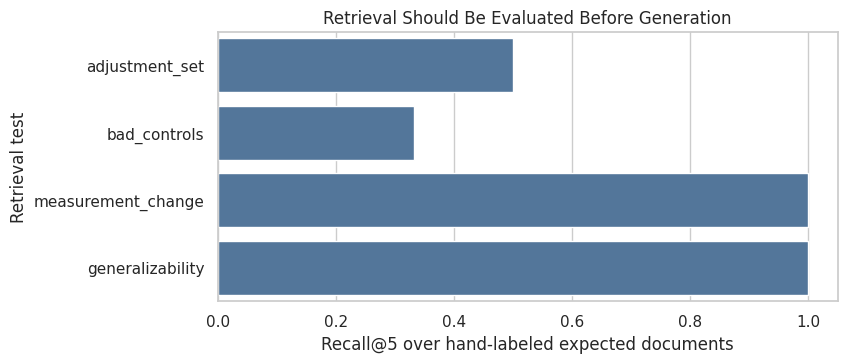

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(data=retrieval_eval, x='recall_at_5', y='case_id', color='#4776A6', ax=ax)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Recall@5 over hand-labeled expected documents')
ax.set_ylabel('Retrieval test')
ax.set_title('Retrieval Should Be Evaluated Before Generation')
plt.show()


### Discussion

This retrieval metric is intentionally simple. It tells us whether the correct source documents appear in the top five chunks. It does not tell us whether the final answer is correct. That is the next layer: answer grounding.


## 7. Query Rewriting for Causal Questions

Business questions are usually too broad for retrieval. A useful RAG system expands the question into causal subquestions.


In [11]:
def causal_query_rewrites(question):
    templates = [
        'treatment assignment rollout eligibility rules for: {question}',
        'outcome metric definition measurement change guardrail for: {question}',
        'pre-treatment confounders controls baseline variables for: {question}',
        'post-treatment mediators bad controls colliders for: {question}',
        'limitations assumptions compliance data lineage for: {question}',
    ]
    return [template.format(question=question) for template in templates]

business_question = 'Did enabling the AI support assistant reduce human-handled workload without harming customer experience?'
rewrites = causal_query_rewrites(business_question)
pd.DataFrame({'rewrite_id': range(1, len(rewrites) + 1), 'query': rewrites})


,rewrite_id,query
0,1,treatment assignment rollout eligibility rules for: Did enabling the AI support assistant reduce human-handled workl...
1,2,outcome metric definition measurement change guardrail for: Did enabling the AI support assistant reduce human-handl...
2,3,pre-treatment confounders controls baseline variables for: Did enabling the AI support assistant reduce human-handle...
3,4,post-treatment mediators bad controls colliders for: Did enabling the AI support assistant reduce human-handled work...
4,5,limitations assumptions compliance data lineage for: Did enabling the AI support assistant reduce human-handled work...


In [12]:
def multi_query_search(question, top_k_per_query=3, final_k=7):
    rows = []
    for rewrite_id, rewritten_query in enumerate(causal_query_rewrites(question), start=1):
        hits = retriever.search(rewritten_query, top_k=top_k_per_query).copy()
        hits['rewrite_id'] = rewrite_id
        hits['rewritten_query'] = rewritten_query
        rows.append(hits)
    all_hits = pd.concat(rows, ignore_index=True)
    aggregated = (
        all_hits.groupby(['chunk_id', 'doc_id', 'title', 'source_type', 'date', 'text'], as_index=False)
        .agg(max_score=('score', 'max'), mean_score=('score', 'mean'), retrieved_by=('rewrite_id', lambda x: sorted(set(x))))
        .sort_values(['max_score', 'mean_score'], ascending=False)
        .head(final_k)
        .reset_index(drop=True)
    )
    return aggregated

retrieved_context = multi_query_search(business_question, top_k_per_query=4, final_k=7)
retrieved_context[['chunk_id', 'title', 'source_type', 'max_score', 'retrieved_by', 'text']]


,chunk_id,title,source_type,max_score,retrieved_by,text
0,metric_dictionary_2025_03::chunk_01,Support Metric Dictionary,metric dictionary,0.332637,"[1, 2, 3, 4, 5]",Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hour...
1,rollout_memo_2025_03::chunk_01,AI Support Assistant Rollout Memo,rollout memo,0.247362,"[1, 2, 3, 4, 5]","The AI support assistant will be enabled first for queues with high prior ticket volume, long baseline backlog, and ..."
2,reporting_standard_2025::chunk_01,Causal Reporting Standard,analysis standard,0.201754,[4],Causal reports should distinguish total effects from direct effects. Post-treatment mediators should not be included...
3,logging_change_2025_03_18::chunk_01,Deflection Logging Change Note,data lineage note,0.148801,"[1, 2, 3, 4, 5]","On March 18, deflection logging changed from session-level capture to ticket-thread capture. The change affects meas..."
4,quality_review_policy_2025::chunk_01,Executive Quality Review Policy,quality policy,0.102647,[3],"Executive review is triggered by high reopen rates, unusual CSAT drops, or visibility from strategic accounts. Teams..."
5,staffing_policy_2025_q1::chunk_01,Support Staffing Policy Q1,operations policy,0.061225,[1],"Staffing levels are adjusted monthly based on forecast demand, backlog, and planned product launches. Staffing decis..."
6,privacy_note_2025::chunk_01,Customer Data Privacy Note,compliance note,0.058631,"[2, 5]",Free-text customer messages may be used for aggregate model diagnostics only after redaction. Analyst-facing reports...


### Discussion

The multi-query strategy is useful because causal questions have multiple evidence targets. One query may find rollout rules, while another finds measurement changes or guardrails. For production work, each rewrite can be logged so analysts know why a source appeared.


## 8. Building a Causal RAG Context Window

A causal RAG prompt should make the source boundary explicit. The model should know what counts as evidence and what does not.


In [13]:
def format_context(retrieved_rows):
    blocks = []
    for _, row in retrieved_rows.iterrows():
        blocks.append(
            textwrap.dedent(
                f'''
                [source_id: {row['chunk_id']}]
                title: {row['title']}
                source_type: {row['source_type']}
                date: {row['date']}
                text: {row['text']}
                '''
            ).strip()
        )
    return '\n\n'.join(blocks)

context_text = format_context(retrieved_context)
print(context_text[:2400])


[source_id: metric_dictionary_2025_03::chunk_01]
title: Support Metric Dictionary
source_type: metric dictionary
date: 2025-03-05
text: Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hours. Ticket deflection is the share of customer issues resolved by self-service or AI before human assignment. CSAT is collected after ticket closure and should be interpreted as a customer-experience outcome or guardrail. Reopen rate is the fraction of resolved tickets reopened within seven days and is also a guardrail outcome.

[source_id: rollout_memo_2025_03::chunk_01]
title: AI Support Assistant Rollout Memo
source_type: rollout memo
date: 2025-03-01
text: The AI support assistant will be enabled first for queues with high prior ticket volume, long baseline backlog, and managers who request early access. Enablement is controlled at the team-week level. Teams with incomplete knowledge-base coverage or unresolved data-quality incidents w

## 9. A Structured Causal RAG Answer Schema

The schema below is deliberately more demanding than a normal answer. It forces the LLM to separate the answer, retrieved evidence, causal assumptions, caveats, abstentions, and recommended next steps.

This separation is essential. It keeps the model from turning retrieved business notes into overconfident causal conclusions.


In [14]:
class EvidenceItem(BaseModel):
    source_id: str
    claim_supported: str


class CausalRAGAnswer(BaseModel):
    question: str
    short_answer: str
    evidence: list[EvidenceItem] = Field(default_factory=list)
    assumptions_from_sources: list[str] = Field(default_factory=list)
    causal_caveats: list[str] = Field(default_factory=list)
    abstentions: list[str] = Field(default_factory=list)
    recommended_next_steps: list[str] = Field(default_factory=list)
    final_confidence: Literal['low', 'medium', 'high']


In [15]:
FALLBACK_RAG_ANSWER = CausalRAGAnswer(
    question=business_question,
    short_answer=(
        'The retrieved sources support a cautious design story, not a causal conclusion by themselves. '
        'Assistant enablement was not randomized and appears related to prior queue pressure, backlog, readiness, staffing, '
        'and manager request. Human-handled workload is the main outcome, while CSAT and reopen rate should be treated as guardrails.'
    ),
    evidence=[
        EvidenceItem(source_id='rollout_memo_2025_03::chunk_01', claim_supported='Rollout was not randomized and prioritized high-volume, high-backlog, manager-requested queues.'),
        EvidenceItem(source_id='metric_dictionary_2025_03::chunk_01', claim_supported='Human-handled workload is the main operational outcome; CSAT and reopen rate are guardrail outcomes.'),
        EvidenceItem(source_id='staffing_policy_2025_q1::chunk_01', claim_supported='Staffing decisions are made before assistant enablement and may affect rollout priority and workload.'),
        EvidenceItem(source_id='reporting_standard_2025::chunk_01', claim_supported='Total-effect reports should not adjust for post-treatment mediators.'),
    ],
    assumptions_from_sources=[
        'Queue volume, baseline backlog, readiness, staffing, and manager request should be considered pre-treatment adjustment candidates.',
        'Ticket deflection and agent adoption are likely post-treatment mechanisms for the total effect.',
        'Guardrails such as CSAT and reopen rate should be analyzed as outcomes rather than controls.',
    ],
    causal_caveats=[
        'RAG does not verify exchangeability; it only surfaces documents relevant to the assumption.',
        'The rollout memo says assignment was not randomized, so naive treated-versus-control comparisons are not credible.',
        'The deflection logging change may affect mediator measurement during the study window.',
    ],
    abstentions=[
        'The retrieved context is not enough to estimate the treatment effect.',
        'The retrieved context is not enough to claim the assistant caused workload reduction.',
    ],
    recommended_next_steps=[
        'Build a panel dataset at team-week level with pre-treatment controls from the retrieved documents.',
        'Estimate the total effect separately from guardrail outcomes.',
        'Run sensitivity checks for unobserved urgency or operational pressure proxied by manager request.',
    ],
    final_confidence='medium',
)
FALLBACK_RAG_JSON = FALLBACK_RAG_ANSWER.model_dump_json(indent=2)
print(FALLBACK_RAG_JSON[:1800])


{
  "question": "Did enabling the AI support assistant reduce human-handled workload without harming customer experience?",
  "short_answer": "The retrieved sources support a cautious design story, not a causal conclusion by themselves. Assistant enablement was not randomized and appears related to prior queue pressure, backlog, readiness, staffing, and manager request. Human-handled workload is the main outcome, while CSAT and reopen rate should be treated as guardrails.",
  "evidence": [
    {
      "source_id": "rollout_memo_2025_03::chunk_01",
      "claim_supported": "Rollout was not randomized and prioritized high-volume, high-backlog, manager-requested queues."
    },
    {
      "source_id": "metric_dictionary_2025_03::chunk_01",
      "claim_supported": "Human-handled workload is the main operational outcome; CSAT and reopen rate are guardrail outcomes."
    },
    {
      "source_id": "staffing_policy_2025_q1::chunk_01",
      "claim_supported": "Staffing decisions are made b

## 10. Deterministic Extractive Baseline

Before trusting an LLM, build a simple baseline that extracts the most relevant source snippets. This gives you a sanity check for what the model should cite.


In [16]:
def extractive_causal_baseline(question, retrieved_rows):
    evidence = []
    for _, row in retrieved_rows.head(5).iterrows():
        evidence.append(
            {
                'source_id': row['chunk_id'],
                'claim_supported': row['text'][:220] + ('...' if len(row['text']) > 220 else ''),
            }
        )
    return CausalRAGAnswer(
        question=question,
        short_answer='This extractive baseline only summarizes retrieved sources and does not estimate a causal effect.',
        evidence=[EvidenceItem(**item) for item in evidence],
        assumptions_from_sources=['Review retrieved chunks for treatment assignment, pre-treatment controls, bad controls, and metric definitions.'],
        causal_caveats=['This baseline does not reason beyond the retrieved snippets.'],
        abstentions=['No causal effect estimate is produced.'],
        recommended_next_steps=['Use the retrieved source IDs to draft a causal design document.'],
        final_confidence='low',
    )

extractive_answer = extractive_causal_baseline(business_question, retrieved_context)
extractive_answer


CausalRAGAnswer(question='Did enabling the AI support assistant reduce human-handled workload without harming customer experience?', short_answer='This extractive baseline only summarizes retrieved sources and does not estimate a causal effect.', evidence=[EvidenceItem(source_id='metric_dictionary_2025_03::chunk_01', claim_supported='Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hours. Ticket deflection is the share of customer issues resolved by self-service or AI before human assignm...'), EvidenceItem(source_id='rollout_memo_2025_03::chunk_01', claim_supported='The AI support assistant will be enabled first for queues with high prior ticket volume, long baseline backlog, and managers who request early access. Enablement is controlled at the team-week level. Teams with incomplet...'), EvidenceItem(source_id='reporting_standard_2025::chunk_01', claim_supported='Causal reports should distinguish total effects from direct

## 11. Optional Local LLM RAG Answer

The live call is off by default. When you enable it, the model receives only the business question and retrieved context. The prompt explicitly forbids unsupported causal conclusions.


In [17]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    DEFAULT_MODELS_TO_COMPARE,
    build_chat_inputs,
    clean_generated_text,
    clear_loaded_model_cache,
    decode_generated_response,
    format_chat_prompt,
    get_device,
    has_package,
    load_local_model as _shared_load_local_model,
    local_chat as _shared_local_chat,
    move_inputs_to_model_device,
    prepare_chat_inputs,
    set_generation_seed,
)

DEVICE = get_device()


def load_local_model(model_id=MODEL_ID):
    return _shared_load_local_model(model_id)


def decode_generated_text(tokenizer, generated, prompt_token_count, model_id=MODEL_ID):
    return decode_generated_response(tokenizer, generated, prompt_token_count, model_id=model_id)


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    enabled = globals().get('RUN_LIVE_LOCAL_LLM', globals().get('RUN_LOCAL_LLM', True))
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=enabled,
    )


def local_generate(user_message, system_message=None, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=MODEL_ID,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=globals().get('SEED', 123),
        enabled=globals().get('RUN_LOCAL_LLM', globals().get('RUN_LIVE_LOCAL_LLM', True)),
    )


In [18]:
SYSTEM_RAG_MESSAGE = textwrap.dedent(
    '''
    You are a careful causal inference assistant using retrieval-augmented generation.
    Use only the retrieved sources as evidence. Do not infer facts that are not in the context.
    The retrieved context is domain evidence, not an effect estimate.
    Never say the assistant reduced workload, caused an outcome, or harmed customer experience unless the context contains an actual causal estimate.
    Prefer cautious language: the sources support a design concern, assumption, caveat, or next analysis step.
    Return valid JSON only when asked for JSON.
    '''
).strip()

RAG_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Business question:
    {question}

    Retrieved context:
    {context}

    Draft a causal RAG answer. Return valid JSON only with exactly these keys:
    question, short_answer, evidence, assumptions_from_sources, causal_caveats,
    abstentions, recommended_next_steps, final_confidence.

    evidence must be an array of objects with keys:
    source_id, claim_supported.

    Field type requirements:
    - claim_supported must be a short string, never true/false.
    - assumptions_from_sources, causal_caveats, abstentions, and recommended_next_steps must be arrays of strings, never objects.
    - final_confidence must be one of: low, medium, high.

    Causal safety requirements:
    - The short_answer must explicitly say the retrieved sources do not establish the causal effect by themselves.
    - Do not write that the assistant reduced workload. Instead say the sources define the outcome and describe non-random rollout.
    - Mention non-random rollout, guardrail outcomes, and post-treatment mediator/bad-control risk.
    - Do not invent independence assumptions. If a source says staffing, readiness, backlog, queue pressure, or manager request affects rollout or workload, phrase it as a possible pre-treatment confounder or design concern.
    - Include at least one abstention saying that the retrieved context cannot estimate or prove a causal effect.

    Citation requirements:
    - Cite source_id values exactly as shown in the retrieved context.
    - Use at least three cited evidence items when possible.
    - Each claim_supported string should state what that specific source supports.
    - Do not cite source IDs that are not in the retrieved context.

    Keep every list item concise.
    Do not include markdown fences, prose before JSON, or prose after JSON.
    '''
).strip()


def rag_prompt(question=business_question, retrieved_rows=retrieved_context):
    return RAG_PROMPT_TEMPLATE.format(question=question, context=format_context(retrieved_rows))


def rag_answer_llm(question=business_question, retrieved_rows=retrieved_context, model_id=MODEL_ID):
    if RUN_LIVE_LOCAL_LLM:
        return local_chat(
            rag_prompt(question, retrieved_rows),
            system_message=SYSTEM_RAG_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
    return FALLBACK_RAG_JSON

raw_rag_answer = rag_answer_llm()
print(raw_rag_answer[:1800])


{
 "question": "Did enabling the AI support assistant reduce human-handled workload without harming customer experience?",
 "short_answer": "The retrieved sources do not establish the causal effect by themselves.",
 "evidence": [
 {
 "source_id": "metric_dictionary_2025_03::chunk_01",
 "claim_supported": "Human-handled workload and reopen rate definitions are provided."
 },
 {
 "source_id": "rollout_memo_2025_03::chunk_01",
 "claim_supported": "Non-random rollout process is described."
 },
 {
 "source_id": "reporting_standard_2025::chunk_01",
 "claim_supported": "Guardrail outcomes should be reported separately."
 }
 ],
 "assumptions_from_sources": [
 "Staffing levels may affect workload per agent and queue prioritization.",
 "Manager requests and readiness checks influence rollout timing."
 ],
 "causal_caveats": [
 "Post-treatment mediators (like deflection) should not be included as controls for total-effect estimates.",
 "Executive review is not a clean pre-treatment control due to 

## 12. Parsing, Normalizing, and Auditing RAG Answers

Structured output is not enough. A model can return valid JSON and still cite missing sources, omit caveats, or claim too much. We therefore audit both schema and substance.


In [19]:
def extract_json_object(text):
    cleaned = clean_generated_text(text)
    cleaned = re.sub(r'^```(?:json)?\s*', '', cleaned.strip())
    cleaned = re.sub(r'\s*```$', '', cleaned.strip())
    start = cleaned.find('{')
    end = cleaned.rfind('}')
    if start == -1 or end == -1 or end <= start:
        return None
    return cleaned[start : end + 1]


def text_from_generated_value(value, fallback='not specified'):
    if value is None:
        return ''
    if isinstance(value, bool):
        return fallback
    if isinstance(value, (int, float)):
        return str(value)
    if isinstance(value, list):
        values = [text_from_generated_value(item, fallback=fallback) for item in value]
        return '; '.join(item for item in values if item)
    if isinstance(value, dict):
        source_id = value.get('source_id') or value.get('citation') or value.get('source') or ''
        for key in ['claim_supported', 'claim', 'text', 'value', 'rationale', 'assumption', 'caveat']:
            if key in value:
                text = text_from_generated_value(value[key], fallback='')
                if text:
                    return f'{text} Source: {source_id}.' if source_id and source_id not in text else text
        return f'Cited {source_id} without a specific text claim.' if source_id else json.dumps(value)
    return clean_generated_text(value)


def coerce_string_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        items = re.split(r';|\n', value) if (';' in value or '\n' in value) else [value]
    else:
        items = [value]
    out = [text_from_generated_value(item, fallback='cited source without a specific text claim') for item in items]
    return [item for item in out if item]


def normalize_source_id(source_id, valid_source_ids):
    source_id = clean_generated_text(source_id)
    if source_id in valid_source_ids:
        return source_id, []
    compact = source_id.replace(' ', '').replace('`', '')
    if compact in valid_source_ids:
        return compact, [f'normalized source_id {source_id!r} to {compact!r}']
    for valid in valid_source_ids:
        if valid.startswith(source_id + '::'):
            return valid, [f'mapped document-level citation {source_id!r} to chunk {valid!r}']
    return source_id, []


def normalize_evidence_items(value, valid_source_ids):
    notes = []
    if isinstance(value, dict):
        value = [{'source_id': key, 'claim_supported': val} for key, val in value.items()]
        notes.append('coerced evidence from object to list')
    if not isinstance(value, list):
        value = []
        notes.append('coerced invalid evidence to empty list')
    evidence = []
    for idx, item in enumerate(value):
        if isinstance(item, str):
            item = {'source_id': '', 'claim_supported': item}
            notes.append(f'coerced evidence[{idx}] from string to object')
        item = dict(item)
        item.setdefault('source_id', item.get('citation') or item.get('source') or '')
        item.setdefault('claim_supported', item.get('claim') or item.get('text') or '')
        normalized_source, source_notes = normalize_source_id(item['source_id'], valid_source_ids)
        item['source_id'] = normalized_source
        if isinstance(item.get('claim_supported'), bool):
            notes.append(f'evidence[{idx}]: converted boolean claim_supported to a placeholder text claim')
            item['claim_supported'] = f'Cited {normalized_source or "a source"} without a specific text claim.'
        else:
            item['claim_supported'] = text_from_generated_value(item.get('claim_supported'), fallback=f'Cited {normalized_source or "a source"} without a specific text claim.')
        notes.extend(f'evidence[{idx}]: {note}' for note in source_notes)
        evidence.append(item)
    return evidence, notes


def coerce_rag_answer(candidate, valid_source_ids):
    data = json.loads(candidate)
    notes = []
    for field in ['question', 'short_answer', 'final_confidence']:
        data.setdefault(field, '')
        data[field] = clean_generated_text(data[field])
    confidence = data['final_confidence'].lower().strip()
    if confidence not in {'low', 'medium', 'high'}:
        notes.append(f'normalized final_confidence {data["final_confidence"]!r} to medium')
        confidence = 'medium'
    data['final_confidence'] = confidence
    evidence, evidence_notes = normalize_evidence_items(data.get('evidence', []), valid_source_ids)
    data['evidence'] = evidence
    for field in ['assumptions_from_sources', 'causal_caveats', 'abstentions', 'recommended_next_steps']:
        data[field] = coerce_string_list(data.get(field, []))
    notes.extend(evidence_notes)
    return json.dumps(data), notes


def parse_rag_answer(raw_output, valid_source_ids):
    candidates = [clean_generated_text(raw_output)]
    extracted = extract_json_object(raw_output)
    if extracted is not None and extracted not in candidates:
        candidates.append(extracted)
    errors = []
    for candidate in candidates:
        try:
            return CausalRAGAnswer.model_validate_json(candidate), candidate, errors
        except ValidationError as error:
            errors.append(error.errors()[0]['msg'])
        except ValueError as error:
            errors.append(str(error).splitlines()[0])
        try:
            repaired_candidate, repair_notes = coerce_rag_answer(candidate, valid_source_ids)
            return CausalRAGAnswer.model_validate_json(repaired_candidate), repaired_candidate, errors + repair_notes
        except (TypeError, json.JSONDecodeError, ValidationError) as error:
            errors.append(str(error).splitlines()[0])
    raise ValueError(f'No valid CausalRAGAnswer found. Parser errors: {errors}')

valid_source_ids = set(retrieved_context['chunk_id'])
parsed_rag_answer, rag_json_used, rag_parser_notes = parse_rag_answer(raw_rag_answer, valid_source_ids)
if rag_parser_notes:
    print('Parser notes:')
    print(rag_parser_notes[:12])
parsed_rag_answer


CausalRAGAnswer(question='Did enabling the AI support assistant reduce human-handled workload without harming customer experience?', short_answer='The retrieved sources do not establish the causal effect by themselves.', evidence=[EvidenceItem(source_id='metric_dictionary_2025_03::chunk_01', claim_supported='Human-handled workload and reopen rate definitions are provided.'), EvidenceItem(source_id='rollout_memo_2025_03::chunk_01', claim_supported='Non-random rollout process is described.'), EvidenceItem(source_id='reporting_standard_2025::chunk_01', claim_supported='Guardrail outcomes should be reported separately.')], assumptions_from_sources=['Staffing levels may affect workload per agent and queue prioritization.', 'Manager requests and readiness checks influence rollout timing.'], causal_caveats=['Post-treatment mediators (like deflection) should not be included as controls for total-effect estimates.', 'Executive review is not a clean pre-treatment control due to visibility from s

In [20]:
def audit_rag_answer(answer, retrieved_rows):
    valid_source_ids = set(retrieved_rows['chunk_id'])
    source_text_by_id = dict(zip(retrieved_rows['chunk_id'], retrieved_rows['text']))
    issues = []

    cited_ids = [item.source_id for item in answer.evidence]
    for source_id in cited_ids:
        if source_id not in valid_source_ids:
            issues.append({'area': 'citation', 'issue': 'citation not present in retrieved context', 'detail': source_id})

    if len(set(cited_ids).intersection(valid_source_ids)) < 3:
        issues.append({'area': 'citation', 'issue': 'fewer than three valid cited sources', 'detail': ', '.join(cited_ids)})

    answer_text = clean_generated_text(
        ' '.join(
            [
                answer.short_answer,
                ' '.join(item.claim_supported for item in answer.evidence),
                ' '.join(answer.assumptions_from_sources),
                ' '.join(answer.causal_caveats),
                ' '.join(answer.abstentions),
                ' '.join(answer.recommended_next_steps),
            ]
        )
    ).lower()

    overclaim_patterns = [
        'proves that the assistant caused',
        'confirms the assistant caused',
        'definitively caused',
        'causal effect is established',
        'assistant reduced human-handled workload',
        'support assistant reduced human-handled workload',
        'assistant reduced workload',
    ]
    for pattern in overclaim_patterns:
        if pattern in answer_text:
            issues.append({'area': 'causal overclaim', 'issue': 'unsupported causal certainty', 'detail': pattern})

    if not any('not enough' in item.lower() or 'cannot' in item.lower() or 'does not' in item.lower() for item in answer.abstentions + answer.causal_caveats):
        issues.append({'area': 'abstention', 'issue': 'missing clear limitation on what RAG cannot establish', 'detail': ''})

    if 'randomized' not in answer_text and 'not randomized' not in answer_text:
        issues.append({'area': 'design', 'issue': 'does not mention non-random rollout evidence', 'detail': ''})

    if 'guardrail' not in answer_text and 'csat' not in answer_text and 'reopen' not in answer_text:
        issues.append({'area': 'outcomes', 'issue': 'does not mention guardrail outcomes', 'detail': ''})

    if 'post-treatment' not in answer_text and 'mediator' not in answer_text:
        issues.append({'area': 'bad controls', 'issue': 'does not warn about mediators or post-treatment controls', 'detail': ''})

    for evidence in answer.evidence:
        source_text = source_text_by_id.get(evidence.source_id, '').lower()
        claim_tokens = {token for token in re.findall(r'[a-z]{4,}', evidence.claim_supported.lower()) if token not in {'that', 'this', 'with', 'from', 'should', 'would', 'could'}}
        source_tokens = set(re.findall(r'[a-z]{4,}', source_text))
        overlap = claim_tokens.intersection(source_tokens)
        if evidence.source_id in valid_source_ids and len(claim_tokens) >= 4 and len(overlap) < 2:
            issues.append({'area': 'grounding', 'issue': 'citation claim has low lexical overlap with source text', 'detail': evidence.source_id})

    return pd.DataFrame(issues, columns=['area', 'issue', 'detail'])

rag_audit = audit_rag_answer(parsed_rag_answer, retrieved_context)
rag_audit


,area,issue,detail
0,grounding,citation claim has low lexical overlap with source text,rollout_memo_2025_03::chunk_01


### Discussion

If the audit is empty, that does not mean the answer is causally true. It means the answer passed a set of basic guardrails:

- citations refer to retrieved chunks,
- the model did not overclaim causal identification,
- key design caveats are present,
- and cited claims are not obviously detached from source text.

In production, this audit should be stricter and task-specific.


## 13. RAG Answer as a Report Component

A RAG answer should become a documented design input, not the final causal estimate. The table below converts the structured answer into an analyst-review format.


In [21]:
def answer_to_review_table(answer):
    rows = []
    for item in answer.evidence:
        rows.append({'section': 'evidence', 'item': item.claim_supported, 'source_id': item.source_id})
    for item in answer.assumptions_from_sources:
        rows.append({'section': 'assumption surfaced from sources', 'item': item, 'source_id': ''})
    for item in answer.causal_caveats:
        rows.append({'section': 'causal caveat', 'item': item, 'source_id': ''})
    for item in answer.abstentions:
        rows.append({'section': 'abstention', 'item': item, 'source_id': ''})
    for item in answer.recommended_next_steps:
        rows.append({'section': 'next step', 'item': item, 'source_id': ''})
    return pd.DataFrame(rows)

review_table = answer_to_review_table(parsed_rag_answer)
review_table


,section,item,source_id
0,evidence,Human-handled workload and reopen rate definitions are provided.,metric_dictionary_2025_03::chunk_01
1,evidence,Non-random rollout process is described.,rollout_memo_2025_03::chunk_01
2,evidence,Guardrail outcomes should be reported separately.,reporting_standard_2025::chunk_01
3,assumption surfaced from sources,Staffing levels may affect workload per agent and queue prioritization.,
4,assumption surfaced from sources,Manager requests and readiness checks influence rollout timing.,
5,causal caveat,Post-treatment mediators (like deflection) should not be included as controls for total-effect estimates.,
6,causal caveat,Executive review is not a clean pre-treatment control due to visibility from strategic accounts.,
7,abstention,The retrieved context cannot estimate or prove a causal effect.,
8,next step,Conduct a randomized controlled trial if feasible.,
9,next step,"Collect additional pre-treatment data on staffing, readiness, and backlog.",


## 14. Retrieval Sensitivity: What Happens When Context Is Missing?

A useful RAG system should know when the evidence is incomplete. We can simulate this by removing the reporting standard and quality review policy from the retrieved context.


In [22]:
reduced_context = retrieved_context[~retrieved_context['doc_id'].isin(['reporting_standard_2025', 'quality_review_policy_2025'])].copy()
reduced_context[['chunk_id', 'title', 'source_type', 'text']]


,chunk_id,title,source_type,text
0,metric_dictionary_2025_03::chunk_01,Support Metric Dictionary,metric dictionary,Human-handled workload is defined as resolved tickets that required a human agent touch divided by active agent hour...
1,rollout_memo_2025_03::chunk_01,AI Support Assistant Rollout Memo,rollout memo,"The AI support assistant will be enabled first for queues with high prior ticket volume, long baseline backlog, and ..."
3,logging_change_2025_03_18::chunk_01,Deflection Logging Change Note,data lineage note,"On March 18, deflection logging changed from session-level capture to ticket-thread capture. The change affects meas..."
5,staffing_policy_2025_q1::chunk_01,Support Staffing Policy Q1,operations policy,"Staffing levels are adjusted monthly based on forecast demand, backlog, and planned product launches. Staffing decis..."
6,privacy_note_2025::chunk_01,Customer Data Privacy Note,compliance note,Free-text customer messages may be used for aggregate model diagnostics only after redaction. Analyst-facing reports...


In [23]:
reduced_answer = extractive_causal_baseline(business_question, reduced_context)
reduced_audit = audit_rag_answer(reduced_answer, reduced_context)
print(f'Reduced context sources: {len(reduced_context)}')
reduced_audit


Reduced context sources: 5


,area,issue,detail
0,design,does not mention non-random rollout evidence,
1,outcomes,does not mention guardrail outcomes,
2,bad controls,does not warn about mediators or post-treatment controls,


### Discussion

The reduced context exercise is a reminder that retrieval failures can become reasoning failures. If the model never sees the reporting standard, it may omit the total-effect versus direct-effect distinction. If it never sees the quality review policy, it may fail to identify executive review as a bad control or collider-like variable.


## 15. Optional All-Model Comparison

Because these are live local model calls, the exact ranking may change across model versions, package versions, seeds, tokenizer behavior, prompt wording, and reruns. The durable lesson is the evaluation pattern, not the leaderboard. Treat each table as an empirical snapshot of model behavior under this workflow.


For model-sensitive notebooks, we compare every available local model. For RAG, the score separates three questions:

1. Can the model return the requested schema?
2. Does it cite retrieved sources correctly?
3. Does it avoid unsupported causal overclaims?

The default comparison uses one case to keep runtime manageable. Increase `MODEL_COMPARISON_CASE_LIMIT` to use more cases.

In [24]:
RAG_EVAL_CASES = [
    {
        'case_id': 'assistant_total_effect',
        'question': business_question,
        'retrieved_rows': retrieved_context,
        'required_source_ids': {'rollout_memo_2025_03::chunk_01', 'metric_dictionary_2025_03::chunk_01'},
        'must_mention': ['not randomized', 'guardrail'],
        'forbidden_phrases': ['proves that the assistant caused', 'definitively caused', 'causal effect is established'],
    },
    {
        'case_id': 'deflection_measurement_change',
        'question': 'Can we interpret a March 18 jump in ticket deflection as a causal effect of the assistant?',
        'retrieved_rows': retriever.search('March 18 deflection logging change causal effect assistant', top_k=5),
        'required_source_ids': {'logging_change_2025_03_18::chunk_01'},
        'must_mention': ['logging', 'not be interpreted'],
        'forbidden_phrases': ['causal effect is established', 'assistant caused the jump'],
    },
]

SUMMARY_COLUMNS = ['label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases', 'schema_reliability', 'mean_rag_score', 'failure_types']
CASE_RESULT_COLUMNS = ['label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'rag_score', 'max_rag_score', 'rag_score_share', 'error']

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required CausalRAGAnswer JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def parse_or_repair_rag_answer(raw_output, model_id, valid_source_ids):
    try:
        parsed, parsed_json, notes = parse_rag_answer(raw_output, valid_source_ids)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': notes, 'repair_used': bool(notes), 'repair_stage': 'parser' if notes else 'none', 'repaired_raw_output': ''}
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:6000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(repair_prompt, system_message=SYSTEM_RAG_MESSAGE, model_id=model_id, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE)
        parsed, parsed_json, notes = parse_rag_answer(repaired_raw_output, valid_source_ids)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def score_rag_answer(answer, retrieved_rows, case):
    valid_source_ids = set(retrieved_rows['chunk_id'])
    cited_ids = {item.source_id for item in answer.evidence}
    text = clean_generated_text(
        ' '.join(
            [
                answer.short_answer,
                ' '.join(item.claim_supported for item in answer.evidence),
                ' '.join(answer.assumptions_from_sources),
                ' '.join(answer.causal_caveats),
                ' '.join(answer.abstentions),
                ' '.join(answer.recommended_next_steps),
            ]
        )
    ).lower()
    audit = audit_rag_answer(answer, retrieved_rows)
    checks = {
        'schema has short answer': bool(answer.short_answer.strip()),
        'has at least three evidence items': len(answer.evidence) >= 3,
        'all citations are retrieved': cited_ids.issubset(valid_source_ids),
        'contains required source': bool(set(case['required_source_ids']).intersection(cited_ids)),
        'has assumptions': len(answer.assumptions_from_sources) >= 2,
        'has causal caveats': len(answer.causal_caveats) >= 2,
        'has abstention': len(answer.abstentions) >= 1,
        'has next steps': len(answer.recommended_next_steps) >= 2,
        'mentions required concepts': all(term.lower() in text for term in case['must_mention']),
        'avoids forbidden phrases': not any(phrase.lower() in text for phrase in case['forbidden_phrases']),
        'audit has no critical issues': audit.empty,
        'confidence is not high by default': answer.final_confidence in {'low', 'medium'},
    }
    return int(sum(checks.values())), len(checks), checks, audit


def evaluate_model_on_rag_case(label, model_id, role, case):
    raw_output = repaired_raw_output = parsed_json = ''
    parser_notes = []
    checks = {}
    audit = pd.DataFrame()
    error = error_type = ''
    schema_valid = repair_used = False
    repair_stage = 'none'
    rag_score = np.nan
    max_rag_score = 12
    try:
        raw_output = local_chat(
            rag_prompt(case['question'], case['retrieved_rows']),
            system_message=SYSTEM_RAG_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        valid_source_ids = set(case['retrieved_rows']['chunk_id'])
        parse_result = parse_or_repair_rag_answer(raw_output, model_id, valid_source_ids)
        parsed = parse_result['parsed']
        parsed_json = parse_result['parsed_json']
        parser_notes = parse_result['parser_notes']
        repair_used = parse_result['repair_used']
        repair_stage = parse_result['repair_stage']
        repaired_raw_output = parse_result['repaired_raw_output']
        rag_score, max_rag_score, checks, audit = score_rag_answer(parsed, case['retrieved_rows'], case)
        status = 'ok_after_repair' if repair_used else 'ok'
        schema_valid = True
        error_type = 'none'
    except Exception as exc:
        status = 'schema_error'
        error = clean_generated_text(repr(exc))[:500]
        error_type = classify_structured_output_failure(exc)
    return {
        'summary': {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': status,
            'schema_valid': schema_valid,
            'repair_used': repair_used,
            'repair_stage': repair_stage,
            'error_type': error_type,
            'rag_score': rag_score,
            'max_rag_score': max_rag_score,
            'rag_score_share': rag_score / max_rag_score if schema_valid else 0.0,
            'error': error,
        },
        'artifact': {
            'label': label,
            'model_id': model_id,
            'case_id': case['case_id'],
            'raw_output': raw_output,
            'repaired_raw_output': repaired_raw_output,
            'parsed_json': parsed_json,
            'parser_notes': parser_notes,
            'checks': checks,
            'audit': audit.to_dict(orient='records') if isinstance(audit, pd.DataFrame) else [],
        },
    }


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results.groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_rag_score=('rag_score_share', lambda s: s.fillna(0).mean()),
            failure_types=('error_type', lambda values: ', '.join(sorted({v for v in values if v and v != 'none'}))),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_rag_score', 'schema_reliability'], ascending=False).reset_index(drop=True)


def run_all_model_rag_comparison(models_to_compare=MODELS_TO_COMPARE):
    if not RUN_LIVE_LOCAL_LLM:
        raise RuntimeError('Set RUN_LIVE_LOCAL_LLM = True before running the model comparison.')
    active_cases = RAG_EVAL_CASES[:MODEL_COMPARISON_CASE_LIMIT]
    rows = []
    artifacts = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in active_cases:
            result = evaluate_model_on_rag_case(label, model_id, role, case)
            rows.append(result['summary'])
            artifacts.append(result['artifact'])
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    model_summary = summarize_model_results(case_results)
    return case_results, model_summary, artifacts

if RUN_FULL_MODEL_COMPARISON:
    rag_case_results, rag_model_summary, rag_artifacts = run_all_model_rag_comparison()
else:
    rag_model_summary = pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])
    rag_model_summary['cases'] = 0
    rag_model_summary['schema_valid_cases'] = 0
    rag_model_summary['schema_repaired_cases'] = 0
    rag_model_summary['schema_reliability'] = np.nan
    rag_model_summary['mean_rag_score'] = np.nan
    rag_model_summary['failure_types'] = ''
    rag_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    rag_artifacts = []
    display(Markdown('All-model comparison is configured but not executed. Set `RUN_LIVE_LOCAL_LLM = True` and `RUN_FULL_MODEL_COMPARISON = True` in an interactive GPU session.'))

rag_model_summary


Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_rag_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.0,1.000000,
1,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,0,1.0,1.000000,
2,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,0,1.0,1.000000,
3,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,1,1.0,0.916667,
4,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,0,1.0,0.833333,
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,0,1.0,0.833333,
6,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,0,1.0,0.833333,
7,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.0,0.750000,
8,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,1,1.0,0.333333,


### Inspecting Failed Model Runs

A failed model run now receives zero workflow credit in the summary table instead of producing a `NaN` score. The table below shows the exact failure metadata for those cases.

Two local model families need special handling in this environment: `Mistral Small 24B` is loaded with `Mistral3ForConditionalGeneration` plus a text tokenizer because its local text-only cache may not include image-processor files, and `Phi mini` is loaded with `LlamaTokenizerFast` plus `Phi3Config` because `AutoTokenizer` can hit a generic-config path in some Transformers builds. Those behaviors are now centralized in `notebooks/_shared/local_llm.py`.

In [25]:
failed_model_details = rag_case_results.loc[
    ~rag_case_results['schema_valid'],
    ['label', 'status', 'error_type', 'error'],
].reset_index(drop=True)
failed_model_details


,label,status,error_type,error


### Interpreting Repair Counts

Repairs are not failures by themselves. They are evidence about operational burden.

- `none`: the model produced valid schema immediately.
- `parser`: deterministic cleanup fixed minor formatting or citation issues.
- `model_retry`: the model needed a second prompt to produce parseable JSON.

For production, a model with slightly lower answer quality but much better schema reliability may be easier to operate.


In [26]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(rag_case_results)


,repair_stage,cases
1,none,5
2,parser,3
0,model_retry,1


## 16. Production Design Checklist

A production causal RAG system needs controls that generic RAG demos usually omit.


In [27]:
production_checklist = pd.DataFrame(
    [
        {'area': 'source governance', 'question': 'Does every chunk carry source owner, date, document type, and permission scope?'},
        {'area': 'freshness', 'question': 'Can analysts tell whether a metric definition or rollout rule changed during the analysis window?'},
        {'area': 'retrieval eval', 'question': 'Do hand-labeled causal queries retrieve the expected design documents?'},
        {'area': 'citation audit', 'question': 'Are all generated claims tied to retrieved chunk IDs?'},
        {'area': 'causal caution', 'question': 'Does the answer abstain from causal conclusions that require estimation or assumptions not in evidence?'},
        {'area': 'bad controls', 'question': 'Does the system flag mediators, guardrails, measurement variables, colliders, and post-treatment variables?'},
        {'area': 'privacy', 'question': 'Does the context exclude raw customer text or other sensitive fields that should not appear in reports?'},
        {'area': 'human review', 'question': 'Is there a clear handoff from RAG answer to analyst-owned design document?'},
    ]
)
production_checklist


,area,question
0,source governance,"Does every chunk carry source owner, date, document type, and permission scope?"
1,freshness,Can analysts tell whether a metric definition or rollout rule changed during the analysis window?
2,retrieval eval,Do hand-labeled causal queries retrieve the expected design documents?
3,citation audit,Are all generated claims tied to retrieved chunk IDs?
4,causal caution,Does the answer abstain from causal conclusions that require estimation or assumptions not in evidence?
5,bad controls,"Does the system flag mediators, guardrails, measurement variables, colliders, and post-treatment variables?"
6,privacy,Does the context exclude raw customer text or other sensitive fields that should not appear in reports?
7,human review,Is there a clear handoff from RAG answer to analyst-owned design document?


## 17. Common Failure Modes

1. **Citation laundering**: the model cites a chunk but makes a claim the chunk does not support.
2. **Causal overclaiming**: the model treats retrieved rollout notes as if they identify the causal effect.
3. **Metric drift blindness**: the model ignores that a metric definition changed during the analysis window.
4. **Bad-control recommendations**: the model suggests controlling for mediators, guardrails, or post-treatment review variables.
5. **Permission leakage**: the model retrieves sensitive raw text or sources outside the analyst's permission scope.
6. **Stale source dependence**: the model cites an old policy after newer rules superseded it.
7. **Single-query myopia**: one broad query misses the evidence needed for treatment, outcome, controls, and assumptions.


## 18. Key Takeaways

- RAG is most valuable in causal inference as a **domain evidence layer**.
- Retrieved documents can support treatment definitions, metric definitions, timelines, and assumption discussion.
- Retrieved documents do not prove causal identification by themselves.
- Always evaluate retrieval before evaluating generation.
- Always audit citations, caveats, abstentions, and bad-control recommendations.
- In future notebooks, the same all-model comparison pattern will be used whenever local LLM behavior materially affects the workflow.
